In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [2]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import gpytorch

In [3]:
from gpytorch.models.deep_gps import DeepGP, DeepGPLayer
from gpytorch.variational import VariationalStrategy, CholeskyVariationalDistribution
# from gpytorch.likelihoods import MultitaskGaussianLikelihood
from gpytorch.mlls import VariationalELBO, DeepApproximateMLL

In [4]:
df = pd.read_csv(r"C:\Users\cecil\Cript_Anomalies\BTCUSDT_20180101_20260112.csv", delimiter=";", skiprows=0)
display(df)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,n_trades,taker_buy_base,...,ignore,symbol,interval,log_return,volatility_20,range_hl,trades_per_volume,buy_ratio,z_return,anomaly_simple
0,2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000+00:00,1.675545e+06,1572,63.227133,...,0,BTCUSDT,15m,NaN,NaN,0.023013,12.716799,0.511480,NaN,False
1,2018-01-01 00:15:00+00:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000+00:00,1.321757e+06,1461,47.686389,...,0,BTCUSDT,15m,-0.002587,NaN,0.011000,14.887438,0.485919,-0.691986,False
2,2018-01-01 00:30:00+00:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000+00:00,1.078825e+06,1000,43.710406,...,0,BTCUSDT,15m,-0.003757,NaN,0.007064,12.515012,0.547036,-1.004095,False
3,2018-01-01 00:45:00+00:00,13494.65,13690.87,13450.00,13529.01,141.699719,2018-01-01 00:59:59.999000+00:00,1.917783e+06,1195,73.897993,...,0,BTCUSDT,15m,0.004341,NaN,0.017849,8.433327,0.521511,1.156086,False
4,2018-01-01 01:00:00+00:00,13528.99,13571.74,13402.28,13445.63,72.537533,2018-01-01 01:14:59.999000+00:00,9.778198e+05,898,34.257652,...,0,BTCUSDT,15m,-0.006182,NaN,0.012526,12.379798,0.472275,-1.650855,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281126,2026-01-12 22:30:00+00:00,91269.52,91402.81,91203.69,91339.90,86.681550,2026-01-12 22:44:59.999000+00:00,7.912440e+06,28813,50.482400,...,0,BTCUSDT,15m,0.000771,0.001837,0.002182,332.400609,0.582389,0.203804,False
281127,2026-01-12 22:45:00+00:00,91339.89,91339.90,91214.00,91244.99,60.451790,2026-01-12 22:59:59.999000+00:00,5.517664e+06,19198,18.105290,...,0,BTCUSDT,15m,-0.001040,0.001788,0.001378,317.575377,0.299500,-0.279123,False
281128,2026-01-12 23:00:00+00:00,91244.99,91280.99,91059.88,91160.07,180.361250,2026-01-12 23:14:59.999000+00:00,1.643558e+07,26239,91.014310,...,0,BTCUSDT,15m,-0.000931,0.001721,0.002423,145.480251,0.504622,-0.250178,False
281129,2026-01-12 23:15:00+00:00,91160.07,91282.39,91135.58,91269.34,31.328540,2026-01-12 23:29:59.999000+00:00,2.857620e+06,9456,19.653920,...,0,BTCUSDT,15m,0.001198,0.001643,0.001610,301.833408,0.627349,0.317736,False


In [5]:
def prepare_deepgp_data(df, x_cols, y_col="log_return", train_n=60000):
    d = df.dropna(subset=x_cols + [y_col]).copy()

    X = d[x_cols].astype(float)
    y = d[y_col].astype(float).values

    sx = StandardScaler()
    sy = StandardScaler()

    Xs = sx.fit_transform(X)                 # sin warning: DataFrame
    ys = sy.fit_transform(y.reshape(-1,1)).reshape(-1)

    # recortar train_n si quieres
    if train_n is not None and len(d) > train_n:
        d = d.iloc[:train_n].copy()
        Xs = Xs[:train_n]
        ys = ys[:train_n]

    X_t = torch.tensor(Xs, dtype=torch.float32)
    y_t = torch.tensor(ys, dtype=torch.float32)

    return d, X_t, y_t, sx, sy

In [6]:
def prepare_deepgp_data(df, x_cols, y_col="log_return", train_n=60000):
    d = df.dropna(subset=x_cols + [y_col]).copy()

    X = d[x_cols].astype(float)
    y = d[y_col].astype(float).values

    sx = StandardScaler()
    sy = StandardScaler()

    Xs = sx.fit_transform(X)                 # sin warning: DataFrame
    ys = sy.fit_transform(y.reshape(-1,1)).reshape(-1)

    # recortar train_n si quieres
    if train_n is not None and len(d) > train_n:
        d = d.iloc[:train_n].copy()
        Xs = Xs[:train_n]
        ys = ys[:train_n]

    X_t = torch.tensor(Xs, dtype=torch.float32)
    y_t = torch.tensor(ys, dtype=torch.float32)

    return d, X_t, y_t, sx, sy

In [7]:

class DGPLayer(DeepGPLayer):
    def __init__(self, input_dims, output_dims=None, num_inducing=128):
        """
        output_dims:
          - int (ej. 2): capa con 'batch' de GPs (multi-output vía batch_shape)
          - None: salida escalar (un GP)
        """
        if output_dims is None:
            batch_shape = torch.Size([])
            inducing_points = torch.randn(num_inducing, input_dims)
        else:
            batch_shape = torch.Size([output_dims])
            inducing_points = torch.randn(output_dims, num_inducing, input_dims)

        variational_distribution = CholeskyVariationalDistribution(
            num_inducing_points=num_inducing,
            batch_shape=batch_shape,
        )

        variational_strategy = VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True
        )

        super().__init__(variational_strategy, input_dims, output_dims)

        # NO usar self.batch_shape; usamos batch_shape local
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=batch_shape)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(batch_shape=batch_shape, ard_num_dims=input_dims),
            batch_shape=batch_shape
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class DeepGPModel(DeepGP):
    def __init__(self, input_dim, hidden_dim=2, num_inducing=128):
        super().__init__()
        self.hidden_layer = DGPLayer(input_dims=input_dim, output_dims=hidden_dim, num_inducing=num_inducing)
        self.output_layer = DGPLayer(input_dims=hidden_dim, output_dims=None, num_inducing=num_inducing)
        self.likelihood = gpytorch.likelihoods.GaussianLikelihood()

    def forward(self, x):
        h = self.hidden_layer(x)
        out = self.output_layer(h)
        return out

In [8]:

@torch.no_grad()
def predict_deepgp(model, X, sy, device="cpu"):
    model.eval()
    model.likelihood.eval()

    with gpytorch.settings.fast_pred_var():
        pred_dist = model.likelihood(model(X.to(device)))

        mu_t = pred_dist.mean
        var_t = pred_dist.variance.clamp_min(1e-8)

        # mu_t puede ser [N] o [B, N] (B=hidden_dim u otro batch)
        if mu_t.ndim == 2:
            # promediar sobre batch dims -> [N]
            mu_t = mu_t.mean(dim=0)
            var_t = var_t.mean(dim=0)

        mu = mu_t.detach().cpu().numpy().reshape(-1)     # [N]
        sigma = torch.sqrt(var_t).detach().cpu().numpy().reshape(-1)  # [N]

    # regresar a escala original del target
    mu_real = sy.inverse_transform(mu.reshape(-1, 1)).reshape(-1)
    sigma_real = sigma * float(sy.scale_[0])

    return mu_real, sigma_real


def fit_deep_gp_anomaly(
    df,
    x_cols,
    y_col="log_return",
    contamination=0.01,
    train_n=60000,
    epochs=8,
    batch_size=2048,
    lr=0.01,
    hidden_dim=2,
    num_inducing=128,
    device=None
):
    d, X_t, y_t, sx, sy = prepare_deepgp_data(df, x_cols, y_col=y_col, train_n=train_n)

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = DeepGPModel(input_dim=len(x_cols), hidden_dim=hidden_dim, num_inducing=num_inducing).to(device)
    likelihood = model.likelihood.to(device)

    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    model.train()
    likelihood.train()

    # optimizer = torch.optim.Adam(
    #     [{"params": model.parameters()}, {"params": likelihood.parameters()}],
    #     lr=lr
    # )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    mll = DeepApproximateMLL(
        VariationalELBO(likelihood, model, num_data=X_t.shape[0])
    )

    for ep in range(epochs):
        losses = []
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            out = model(xb)
            loss = -mll(out, yb)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        print(f"Epoch {ep+1}/{epochs} | loss={np.mean(losses):.5f}")

    # scoring sobre el mismo set (puedes aplicar a otro df también)
    mu, sigma = predict_deepgp(model, X_t, sy, device=device)

    N = len(d)
    mu = mu[:N]
    sigma = sigma[:N]

    y_real = d[y_col].values
    z_pred = np.abs(y_real - mu) / np.clip(sigma, 1e-8, None)

    thr = np.quantile(z_pred, 1 - contamination)

    out_df = d.copy()
    out_df["dgp_mu"] = mu
    out_df["dgp_sigma"] = sigma
    out_df["dgp_z"] = z_pred
    out_df["anomaly_dgp"] = (out_df["dgp_z"] >= thr).astype(int)

    return out_df, model, sx, sy, thr

In [9]:
def evaluar_modelo(
    df_result: pd.DataFrame,
    anomaly_col: str = "anomaly_if",
    score_col: str = "if_score",
    zscore_col: str = "anomaly_simple",
    y_true_col: str = None
):
    """
    Calcula métricas estandarizadas para Isolation Forest.

    Métricas:
    - Anomaly Rate
    - Distribución del score
    - Overlap con Z-score, si existe anomaly_simple
    - Precision, Recall, F1 y AUC, si existe variable real y_true_col
    """

    df_eval = df_result.copy()

    # Nos quedamos solo con filas donde el modelo sí predijo
    df_eval = df_eval.dropna(subset=[anomaly_col, score_col])

    y_pred = df_eval[anomaly_col].astype(bool)
    scores = df_eval[score_col].astype(float)

    metricas = {}

    # 1. Total de observaciones evaluadas
    metricas["total_observaciones"] = len(df_eval)

    # 2. Total de anomalías detectadas
    metricas["total_anomalias"] = int(y_pred.sum())

    # 3. Anomaly Rate
    metricas["anomaly_rate"] = y_pred.mean()

    # 4. Distribución del score
    metricas["score_media"] = scores.mean()
    metricas["score_std"] = scores.std()
    metricas["score_min"] = scores.min()
    metricas["score_p50"] = scores.quantile(0.50)
    metricas["score_p95"] = scores.quantile(0.95)
    metricas["score_p99"] = scores.quantile(0.99)
    metricas["score_max"] = scores.max()

    # 5. Overlap con Z-score
    if zscore_col in df_eval.columns:
        z_anom = df_eval[zscore_col].astype(bool)

        anom_modelo = set(df_eval.index[y_pred])
        anom_zscore = set(df_eval.index[z_anom])

        interseccion = anom_modelo.intersection(anom_zscore)

        metricas["zscore_total_anomalias"] = len(anom_zscore)
        metricas["overlap_zscore_n"] = len(interseccion)

        if len(anom_zscore) > 0:
            metricas["overlap_zscore_pct"] = len(interseccion) / len(anom_zscore)
        else:
            metricas["overlap_zscore_pct"] = np.nan

    # 6. Métricas supervisadas si existe etiqueta real
    if y_true_col is not None and y_true_col in df_eval.columns:
        y_true = df_eval[y_true_col].astype(bool)

        metricas["precision"] = precision_score(y_true, y_pred, zero_division=0)
        metricas["recall"] = recall_score(y_true, y_pred, zero_division=0)
        metricas["f1_score"] = f1_score(y_true, y_pred, zero_division=0)

        try:
            metricas["auc"] = roc_auc_score(y_true, scores)
        except ValueError:
            metricas["auc"] = np.nan

    return pd.DataFrame([metricas])

In [10]:

def plot_close_anomalies(df, close_col="close", anomaly_col="anomaly_dgp", title="DeepGP - Anomalías"):
    d = df.copy()
    
    plt.figure(figsize=(14,6))
    plt.plot(d[close_col].values, alpha=0.7, label=close_col)

    an = d[d[anomaly_col] == 1]
    
    plt.scatter(
        an.index,
        an[close_col],
        s=20,
        color="orange",
        label="anomalía"
    )

    plt.title(title)
    plt.legend()
    plt.show()

In [17]:
def plot_pca_score(df, features, score_col, title="PCA 2D coloreado por score", cmap="RdYlGn_r", sample_n=30000, random_state=42):
    d = df.dropna(subset=features + [score_col]).copy()
    if len(d) > sample_n:
        d = d.sample(sample_n, random_state=random_state)

    X = d[features].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.loc[X.index]
    scores = d[score_col].values

    Xs = StandardScaler().fit_transform(X.values)
    X2 = PCA(n_components=2, random_state=random_state).fit_transform(Xs)

    plt.figure()
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=scores, cmap=cmap)
    plt.colorbar(sc, label="Anomaly Score")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [11]:
features = [
    "log_return",
    "volatility_20",
    "range_hl",
    "trades_per_volume",
    "buy_ratio"
]

In [12]:
df_clean = df.copy()

# 1) quitar inf
df_clean[features] = df_clean[features].replace([np.inf, -np.inf], np.nan)

# 2) eliminar filas con NA en features
df_clean = df_clean.dropna(subset=features).reset_index(drop=True)

In [13]:
df_dgp, dgp_model, sx_dgp, sy_dgp, thr_dgp = fit_deep_gp_anomaly(
    df=df_clean,
    x_cols=features,
    y_col="log_return",
    contamination=0.01,
    train_n=60000,
    epochs=6,
    batch_size=512,
    lr=0.01,
    hidden_dim=2,
    num_inducing=64
)

Epoch 1/6 | loss=1.66779
Epoch 2/6 | loss=1.20411
Epoch 3/6 | loss=0.94969
Epoch 4/6 | loss=0.71917
Epoch 5/6 | loss=0.54455
Epoch 6/6 | loss=0.41209


In [15]:
print(df_dgp.columns)

Index(['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'n_trades', 'taker_buy_base', 'taker_buy_quote',
       'ignore', 'symbol', 'interval', 'log_return', 'volatility_20',
       'range_hl', 'trades_per_volume', 'buy_ratio', 'z_return',
       'anomaly_simple', 'dgp_mu', 'dgp_sigma', 'dgp_z', 'anomaly_dgp'],
      dtype='object')


In [16]:
metrics_dgp = evaluar_modelo(
    df_result=df_dgp,
    anomaly_col="anomaly_dgp",
    score_col="dgp_z",
    zscore_col="anomaly_simple"
)

print(metrics_dgp)

   total_observaciones  total_anomalias  anomaly_rate  score_media  score_std  \
0                60000              600          0.01     0.088901   0.753268   

   score_min  score_p50  score_p95  score_p99  score_max  \
0   0.000001   0.051187   0.201074   0.499427   97.87466   

   zscore_total_anomalias  overlap_zscore_n  overlap_zscore_pct  
0                    1939               496            0.255802  


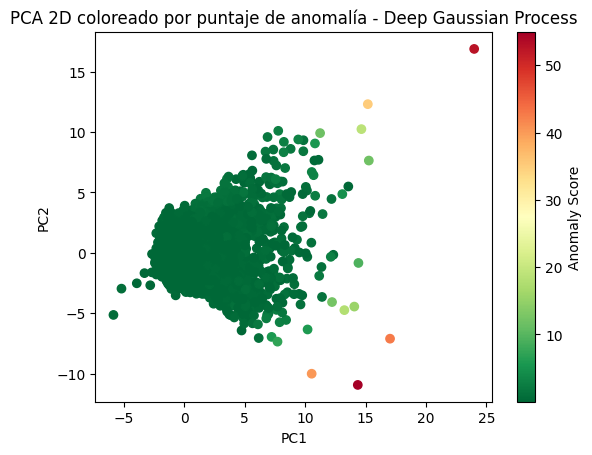

In [20]:
plot_pca_score(
    df=df_dgp,
    features=features,
    score_col="dgp_z",
    title="PCA 2D coloreado por puntaje de anomalía - Deep Gaussian Process"
)

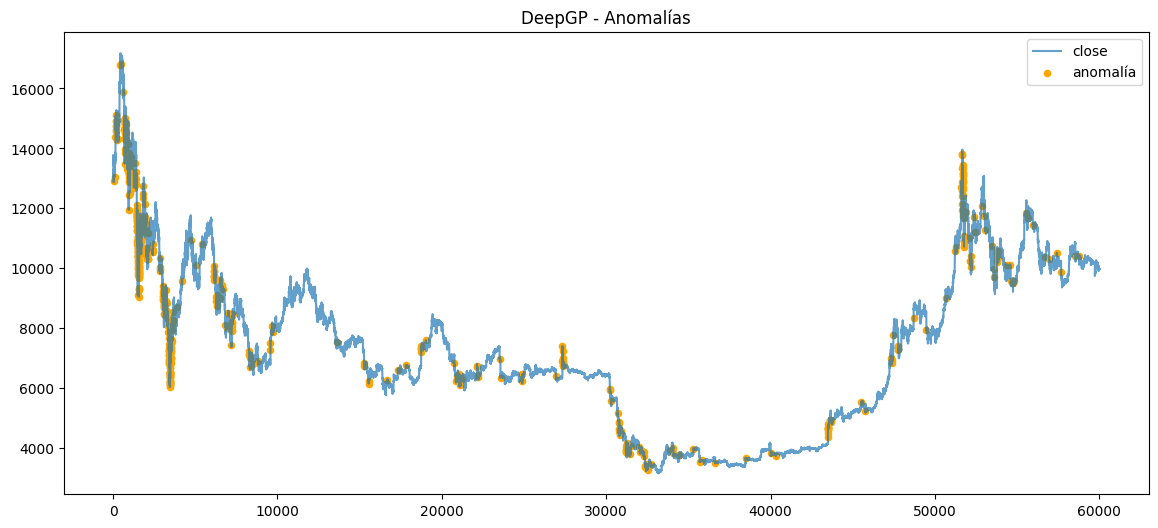

In [58]:
plot_close_anomalies(df_dgp, close_col="close", anomaly_col="anomaly_dgp", title="DeepGP - Anomalías")